<a href="https://colab.research.google.com/github/olithainduvara/FloodLink_2.0/blob/main/EMG_Gesture_Recognition_DS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMG-Based Hand Gesture Recognition — DS1 Dataset
### Undergraduate Final Year Project | Semester 1 ML Pipeline

---

**Project:** EMG-Based Prosthetic Hand Control  
**Dataset:** DS1 — Surface EMG Datasets for Hand Gesture Recognition (MDPI, 2025)  
**Authors:** Zúñiga-Castillo et al., Universidad Autónoma de Querétaro  
**Dataset link:** https://kaggle.com/datasets/d27a113cf8221f4344e5b6834dedc26fb6fbc16c1a9ad28d56cc5d5d77860c40

---



| Step | What we do |
|------|------------|
| 1 | Upload and load the dataset files |
| 2 | Understand the data shape and structure |
| 3 | Visualise raw EMG signals for each gesture |
| 4 | Extract features (RMS, MAV, ZC, WL) from each window |
| 5 | Train a KNN classifier |
| 6 | Evaluate with accuracy + confusion matrix |
| 7 | Train an SVM and compare with KNN |

---

## DS1 Dataset — Quick Reference

| Property | Value |
|----------|-------|
| Subjects | 20 healthy subjects |
| Gestures | 5 (fist, thumb flex, rest, extension, middle+ring flex) |
| Channels | 3 (flexor digitorum superficialis, extensor digitorum, flexor pollicis longus) |
| Sampling rate | 1000 Hz |
| Window size | 200 samples = 200 ms |
| Overlap | 75% (step = 50 samples) |
| Total windows | 174,000 |
| Label encoding | 0=Fist, 1=Thumb flex, 2=Rest, 3=Extension, 4=Middle+Ring flex |

---

## Step 1 — Install Libraries and Upload Files

All libraries below come **pre-installed in Google Colab** — no pip install needed.

You need to upload **two files** from the DS1 dataset zip:
- `EMG_S.mat` — the pre-windowed EMG signal data (174,000 windows)
- `Labels.mat` — the gesture label for each window

Run the cell below, then click the **"Choose Files"** button that appears to upload both files.

In [ ]:
# ── Import all libraries we will use throughout this notebook ──────────────
import numpy as np                          # numerical operations
import scipy.io as sio                      # loading .mat files
import matplotlib.pyplot as plt             # plotting
import matplotlib.patches as mpatches       # legend patches for plots
import seaborn as sns                       # confusion matrix heatmap

from sklearn.model_selection import train_test_split   # split data
from sklearn.neighbors import KNeighborsClassifier      # KNN classifier
from sklearn.svm import SVC                             # SVM classifier
from sklearn.preprocessing import StandardScaler        # feature normalisation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from google.colab import files             # file upload in Colab

print("All libraries imported successfully.")
print()
print("Now upload your files: EMG_S.mat and Labels.mat")
print("Click the 'Choose Files' button below.")

# Upload files from your computer into this Colab session
uploaded = files.upload()

print()
print("Files uploaded:", list(uploaded.keys()))

All libraries imported successfully.

Now upload your files: EMG_S.mat and Labels.mat
Click the 'Choose Files' button below.


In [ ]:
# ── Import all libraries we will use throughout this notebook ──────────────
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from google.colab import drive

print("All libraries imported successfully.")

# Mount Google Drive
drive.mount('/content/drive')

# Change this folder path to where your files are stored in Google Drive
folder_path = '/content/drive/MyDrive/'

# File paths
emg_file = folder_path + 'EMG_S.mat'
labels_file = folder_path + 'Labels.mat'

# Load .mat files
EMG_data = sio.loadmat(emg_file)
Labels_data = sio.loadmat(labels_file)

print("Files loaded successfully from Google Drive.")
print("EMG_S.mat keys:", EMG_data.keys())
print("Labels.mat keys:", Labels_data.keys())

All libraries imported successfully.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files loaded successfully from Google Drive.
EMG_S.mat keys: dict_keys(['__header__', '__version__', '__globals__', 'matriz_ventanas'])
Labels.mat keys: dict_keys(['__header__', '__version__', '__globals__', 'labels'])


---
## Step 2 — Load and Understand the Data

We use `scipy.io.loadmat()` to read the `.mat` files into Python.

After loading, we print the **shape** of each array so we can confirm exactly what we have before doing anything else.

**Expected shapes:**
- `EMG_S` → `(174000, 3, 200)` meaning 174,000 windows, 3 channels, 200 samples each
- `Labels` → `(174000, 5)` meaning one-hot encoded label for each window (5 gesture classes)

> **One-hot encoding** means each label is a row of 5 zeros with a single 1 indicating the gesture.  
> Example: `[1, 0, 0, 0, 0]` = Fist, `[0, 0, 1, 0, 0]` = Rest

In [ ]:
# ── Load EMG_S.mat ─────────────────────────────────────────────────────────
# loadmat() returns a dictionary. The actual data is inside a key.
# We use [k for k in ...] to find the right key automatically.

emg_mat = sio.loadmat('EMG_S.mat')

# Print all keys to see what is inside the file
print("Keys in EMG_S.mat:", [k for k in emg_mat.keys() if not k.startswith('_')])

# ── Load Labels.mat ────────────────────────────────────────────────────────
labels_mat = sio.loadmat('Labels.mat')
print("Keys in Labels.mat:", [k for k in labels_mat.keys() if not k.startswith('_')])

FileNotFoundError: [Errno 2] No such file or directory: 'EMG_S.mat'

In [ ]:
# ── Import all libraries we will use throughout this notebook ──────────────
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from google.colab import drive

print("All libraries imported successfully.")

# ── Mount Google Drive ─────────────────────────────────────────────────────
drive.mount('/content/drive')

# ── Search for EMG_S.mat and Labels.mat inside MyDrive ─────────────────────
search_root = '/content/drive/MyDrive/'

emg_file = None
labels_file = None

for root, dirs, files in os.walk(search_root):
    for file in files:
        if file == 'EMG_S.mat':
            emg_file = os.path.join(root, file)
        elif file == 'Labels.mat':
            labels_file = os.path.join(root, file)

print()
print("EMG_S.mat path:", emg_file)
print("Labels.mat path:", labels_file)

# ── Check whether files were found ─────────────────────────────────────────
if emg_file is None:
    raise FileNotFoundError(
        "EMG_S.mat was not found in MyDrive. "
        "If it is in 'Shared with me', add a shortcut of the folder to My Drive first."
    )

if labels_file is None:
    raise FileNotFoundError(
        "Labels.mat was not found in MyDrive. "
        "If it is in 'Shared with me', add a shortcut of the folder to My Drive first."
    )

# ── Load EMG_S.mat ─────────────────────────────────────────────────────────
emg_mat = sio.loadmat(emg_file)

print()
print("Keys in EMG_S.mat:")
print([k for k in emg_mat.keys() if not k.startswith('_')])

# ── Load Labels.mat ────────────────────────────────────────────────────────
labels_mat = sio.loadmat(labels_file)

print()
print("Keys in Labels.mat:")
print([k for k in labels_mat.keys() if not k.startswith('_')])

print()
print("Files loaded successfully.")

All libraries imported successfully.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

EMG_S.mat path: /content/drive/MyDrive/EMG_S.mat
Labels.mat path: /content/drive/MyDrive/Labels.mat

Keys in EMG_S.mat:
['matriz_ventanas']

Keys in Labels.mat:
['labels']

Files loaded successfully.


In [ ]:
# ── Extract the arrays ─────────────────────────────────────────────────────
# IMPORTANT: Replace 'EMG_S' and 'Labels' below with the actual key names
# printed above if they are different (e.g. 'emg_s', 'label', 'data', etc.)

# Find the data key automatically (first non-underscore key)
emg_key    = [k for k in emg_mat.keys()    if not k.startswith('_')][0]
labels_key = [k for k in labels_mat.keys() if not k.startswith('_')][0]

EMG_S  = emg_mat[emg_key]       # shape: (174000, 3, 200)
Labels = labels_mat[labels_key]  # shape: (174000, 5) one-hot

print("EMG_S shape  :", EMG_S.shape)
print("Labels shape :", Labels.shape)
print()

# ── Convert one-hot labels to integer class labels ─────────────────────────
# np.argmax finds the position of the 1 in each row
# Result: array of integers from 0 to 4
y = np.argmax(Labels, axis=1)

print("Label array (first 10 values):", y[:10])
print()

# ── Show how many windows belong to each gesture ───────────────────────────
gesture_names = [
    '0 — Fist',
    '1 — Thumb flexion',
    '2 — Rest',
    '3 — Extension',
    '4 — Middle + Ring flex'
]

print("Windows per gesture:")
for i, name in enumerate(gesture_names):
    count = np.sum(y == i)
    print(f"  Gesture {name}: {count} windows")

EMG_S shape  : (174000, 3, 200)
Labels shape : (174000, 5)

Label array (first 10 values): [0 0 0 0 0 0 0 0 0 0]

Windows per gesture:
  Gesture 0 — Fist: 34800 windows
  Gesture 1 — Thumb flexion: 34800 windows
  Gesture 2 — Rest: 34800 windows
  Gesture 3 — Extension: 34800 windows
  Gesture 4 — Middle + Ring flex: 34800 windows


---
## Step 3 — Visualise Raw EMG Signals

Before any machine learning, always **look at your data first**.

We will plot one sample window for each of the 5 gestures, showing all 3 channels.

**What you should observe:**
- **Rest (gesture 2):** very low amplitude signal, near zero — no muscle is contracting
- **Fist (gesture 0):** high amplitude especially on Channel 1 (flexor digitorum superficialis)
- **Extension (gesture 3):** high amplitude on Channel 2 (extensor digitorum)
- **Thumb flexion (gesture 1):** noticeable activity on Channel 3 (flexor pollicis longus)

This is exactly the physiology from your anatomy study — you can now **see it in the data**.

| Channel | Muscle | Role |
|---------|--------|------|
| Channel 1 | Flexor digitorum superficialis | Finger closing / gripping |
| Channel 2 | Extensor digitorum | Finger opening / extension |
| Channel 3 | Flexor pollicis longus | Thumb flexion |

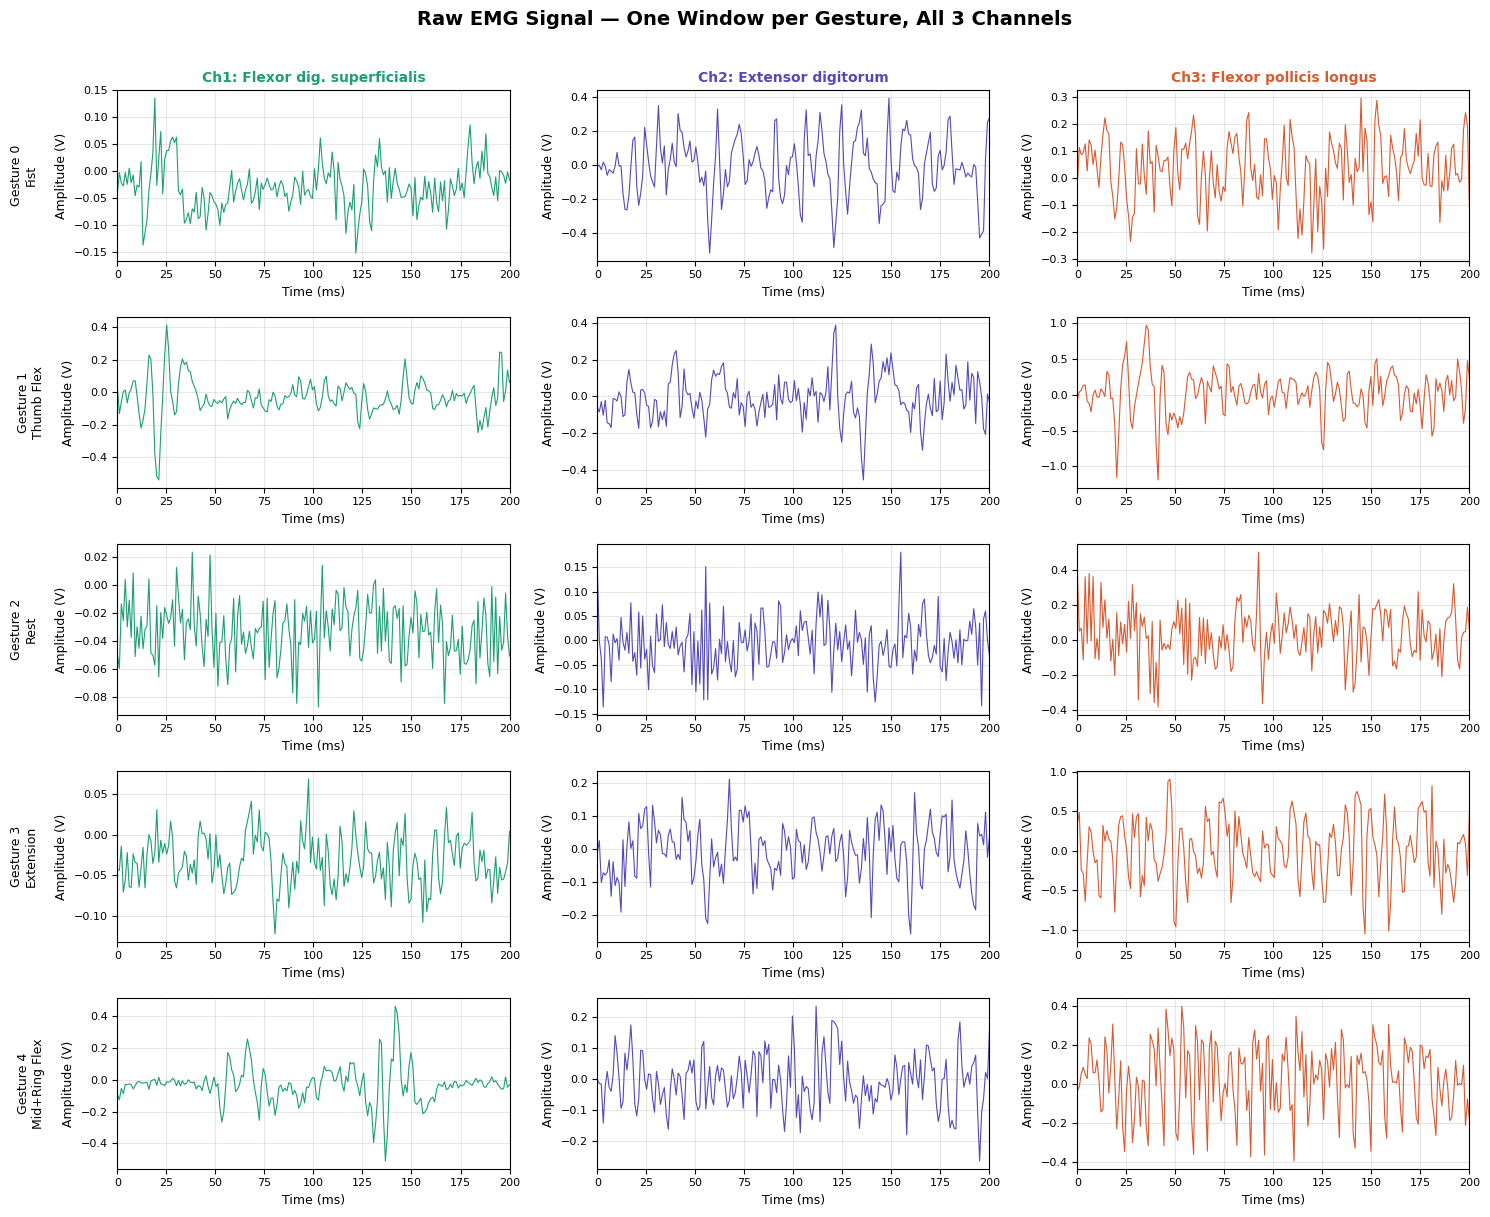

Plot saved as emg_raw_signals.png


In [ ]:
import numpy as np                          # numerical operations

# ── Plot one sample window for each gesture ────────────────────────────────

gesture_labels_short = ['Fist', 'Thumb Flex', 'Rest', 'Extension', 'Mid+Ring Flex']
channel_names = [
    'Ch1: Flexor dig. superficialis',
    'Ch2: Extensor digitorum',
    'Ch3: Flexor pollicis longus'
]
channel_colors = ['#1D9E75', '#534AB7', '#D85A30']   # teal, purple, coral

time_axis = np.linspace(0, 200, 200)   # 200 samples = 200 ms at 1000 Hz

fig, axes = plt.subplots(5, 3, figsize=(15, 12))
fig.suptitle(
    'Raw EMG Signal — One Window per Gesture, All 3 Channels',
    fontsize=14, fontweight='bold', y=1.01
)

for gesture_idx in range(5):

    # Find the first window that belongs to this gesture
    window_indices = np.where(y == gesture_idx)[0]
    sample_window  = EMG_S[window_indices[0]]   # shape: (3, 200)

    for ch in range(3):
        ax = axes[gesture_idx, ch]
        ax.plot(time_axis, sample_window[ch], color=channel_colors[ch], linewidth=0.8)
        ax.set_xlim([0, 200])
        ax.set_xlabel('Time (ms)', fontsize=9)
        ax.set_ylabel('Amplitude (V)', fontsize=9)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.3)

        # Row label (gesture name) on the leftmost column only
        if ch == 0:
            ax.set_ylabel(
                f'Gesture {gesture_idx}\n{gesture_labels_short[gesture_idx]}\n\nAmplitude (V)',
                fontsize=9
            )

        # Column title on the top row only
        if gesture_idx == 0:
            ax.set_title(channel_names[ch], fontsize=10, fontweight='bold', color=channel_colors[ch])

plt.tight_layout()
plt.savefig('emg_raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as emg_raw_signals.png")

---
## Step 4 — Feature Extraction

A machine learning classifier cannot work on raw 200-sample waveforms directly — it needs **numbers that summarise** the signal.

We extract 4 standard time-domain features **per channel per window**. With 3 channels and 4 features, each window becomes a **12-number vector** that the classifier sees.

| Feature | Formula | What it captures |
|---------|---------|------------------|
| RMS — Root Mean Square | √(mean(x²)) | Overall signal energy / contraction strength |
| MAV — Mean Absolute Value | mean(|x|) | Average signal magnitude |
| ZC — Zero Crossings | count of sign changes | Signal frequency content |
| WL — Waveform Length | sum(|x[i] - x[i-1]|) | Signal complexity / total variation |

These are the most commonly used features in EMG classification literature and are exactly what the paper recommends.

In [ ]:
# ── Define feature extraction functions ───────────────────────────────────

def rms(signal):
    """Root Mean Square — measures overall signal energy."""
    return np.sqrt(np.mean(signal ** 2))

def mav(signal):
    """Mean Absolute Value — average signal magnitude."""
    return np.mean(np.abs(signal))

def zero_crossings(signal, threshold=0.0):
    """Zero Crossings — number of times signal crosses zero.
    A threshold avoids counting noise crossings near zero."""
    zc = 0
    for i in range(1, len(signal)):
        if abs(signal[i] - signal[i-1]) > threshold:
            if (signal[i] >= 0 and signal[i-1] < 0) or \
               (signal[i] < 0  and signal[i-1] >= 0):
                zc += 1
    return zc

def waveform_length(signal):
    """Waveform Length — total variation of the signal.
    Captures cumulative signal changes (complexity)."""
    return np.sum(np.abs(np.diff(signal)))

print("Feature functions defined.")
print()

# ── Test on a single window to verify ─────────────────────────────────────
test_window = EMG_S[0]   # shape: (3, 200)
test_ch     = test_window[0]   # Channel 1 only

print("Test on window 0, Channel 1:")
print(f"  RMS : {rms(test_ch):.6f}")
print(f"  MAV : {mav(test_ch):.6f}")
print(f"  ZC  : {zero_crossings(test_ch)}")
print(f"  WL  : {waveform_length(test_ch):.6f}")

Feature functions defined.

Test on window 0, Channel 1:
  RMS : 0.050908
  MAV : 0.040865
  ZC  : 42
  WL  : 6.467431


In [ ]:
# ── Extract features for ALL 174,000 windows ──────────────────────────────
# For each window: compute 4 features × 3 channels = 12 features
# Result: X has shape (174000, 12)

# This may take 1-3 minutes — 174,000 windows is a large dataset
print("Extracting features from all windows...")
print("This may take a few minutes. Please wait.")
print()

num_windows  = EMG_S.shape[0]   # 174,000
num_channels = EMG_S.shape[1]   # 3
num_features = 4                 # RMS, MAV, ZC, WL

X = np.zeros((num_windows, num_channels * num_features))

for i in range(num_windows):

    # Print progress every 10,000 windows
    if i % 10000 == 0:
        print(f"  Processing window {i} / {num_windows} ({100*i//num_windows}%)")

    feature_vector = []

    for ch in range(num_channels):
        sig = EMG_S[i, ch, :]   # one channel of one window: shape (200,)

        feature_vector.append(rms(sig))
        feature_vector.append(mav(sig))
        feature_vector.append(zero_crossings(sig))
        feature_vector.append(waveform_length(sig))

    X[i] = feature_vector

print()
print("Feature extraction complete.")
print(f"Feature matrix X shape: {X.shape}")
print(f"  → {X.shape[0]} windows, each described by {X.shape[1]} features")
print()
print("Feature column names:")
feature_names = []
for ch in range(1, 4):
    for feat in ['RMS', 'MAV', 'ZC', 'WL']:
        feature_names.append(f'Ch{ch}_{feat}')
print(feature_names)

Extracting features from all windows...
This may take a few minutes. Please wait.

  Processing window 0 / 174000 (0%)
  Processing window 10000 / 174000 (5%)
  Processing window 20000 / 174000 (11%)
  Processing window 30000 / 174000 (17%)
  Processing window 40000 / 174000 (22%)
  Processing window 50000 / 174000 (28%)
  Processing window 60000 / 174000 (34%)
  Processing window 70000 / 174000 (40%)
  Processing window 80000 / 174000 (45%)
  Processing window 90000 / 174000 (51%)
  Processing window 100000 / 174000 (57%)
  Processing window 110000 / 174000 (63%)
  Processing window 120000 / 174000 (68%)
  Processing window 130000 / 174000 (74%)
  Processing window 140000 / 174000 (80%)
  Processing window 150000 / 174000 (86%)
  Processing window 160000 / 174000 (91%)
  Processing window 170000 / 174000 (97%)

Feature extraction complete.
Feature matrix X shape: (174000, 12)
  → 174000 windows, each described by 12 features

Feature column names:
['Ch1_RMS', 'Ch1_MAV', 'Ch1_ZC', 'Ch1

---
## Step 5 — Train the KNN Classifier

**KNN (K-Nearest Neighbours)** is the simplest classifier and the best starting point.

**How KNN works (simple explanation):**  
When classifying a new window, KNN looks at the K most similar windows in the training set and takes a vote. If 4 out of 5 nearest neighbours are "Fist", the prediction is "Fist".

**Steps we follow:**
1. Split data into 80% training and 20% testing
2. Normalise features (important — KNN uses distance, so scale matters)
3. Train KNN with K=5
4. Predict on test set

In [ ]:
# ── Split into training and testing sets ──────────────────────────────────
# 80% training, 20% testing
# random_state=42 ensures the same split every time you run this
# stratify=y ensures each gesture is represented equally in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data split:")
print(f"  Training set : {X_train.shape[0]} windows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Testing set  : {X_test.shape[0]} windows ({X_test.shape[0]/len(X)*100:.0f}%)")
print()

# ── Normalise features ─────────────────────────────────────────────────────
# StandardScaler makes each feature have mean=0 and std=1
# This is important for KNN because it uses Euclidean distance.
# Without scaling, a feature with large values (WL) would dominate.
# IMPORTANT: fit only on training data, then transform both train and test

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform training data
X_test  = scaler.transform(X_test)        # transform test data using training stats

print("Features normalised (StandardScaler applied).")
print()

# ── Train KNN classifier ───────────────────────────────────────────────────
# n_neighbors=5 means we look at 5 nearest neighbours
# metric='euclidean' uses straight-line distance between feature vectors

print("Training KNN classifier (k=5)...")
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn.fit(X_train, y_train)

print("KNN training complete.")
print()

# ── Predict on test set ────────────────────────────────────────────────────
print("Predicting on test set...")
y_pred_knn = knn.predict(X_test)
print("Prediction complete.")

Data split:
  Training set : 139200 windows (80%)
  Testing set  : 34800 windows (20%)

Features normalised (StandardScaler applied).

Training KNN classifier (k=5)...
KNN training complete.

Predicting on test set...
Prediction complete.


---
## Step 6 — Evaluate the KNN Classifier

We evaluate using three tools:

1. **Accuracy** — overall percentage of correctly classified windows
2. **Classification report** — precision, recall, and F1-score per gesture
3. **Confusion matrix** — shows which gestures are being confused with each other

**Reading the confusion matrix:**  
- Each **row** = the actual gesture (true label)  
- Each **column** = what the model predicted  
- **Diagonal cells** = correct predictions (higher is better)  
- **Off-diagonal cells** = mistakes (e.g. row 0, col 1 = fist predicted as thumb)

You should expect to see that **Rest** is very easy to classify (very different signal), while gestures that involve similar muscles (e.g. Fist and Middle+Ring flex both activate flexors) may be confused.

In [ ]:
# ── Accuracy ───────────────────────────────────────────────────────────────
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("=" * 50)
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")
print("=" * 50)
print()

# ── Per-gesture classification report ─────────────────────────────────────
# Precision: of all windows predicted as Fist, how many actually were Fist?
# Recall:    of all actual Fist windows, how many did we correctly predict?
# F1-score:  harmonic mean of precision and recall (balanced measure)

print("Classification Report:")
print(classification_report(
    y_test, y_pred_knn,
    target_names=['Fist', 'Thumb Flex', 'Rest', 'Extension', 'Mid+Ring Flex']
))

KNN Accuracy: 90.87%

Classification Report:
               precision    recall  f1-score   support

         Fist       0.89      0.88      0.88      6960
   Thumb Flex       0.87      0.89      0.88      6960
         Rest       0.95      0.94      0.95      6960
    Extension       0.93      0.93      0.93      6960
Mid+Ring Flex       0.90      0.89      0.90      6960

     accuracy                           0.91     34800
    macro avg       0.91      0.91      0.91     34800
 weighted avg       0.91      0.91      0.91     34800



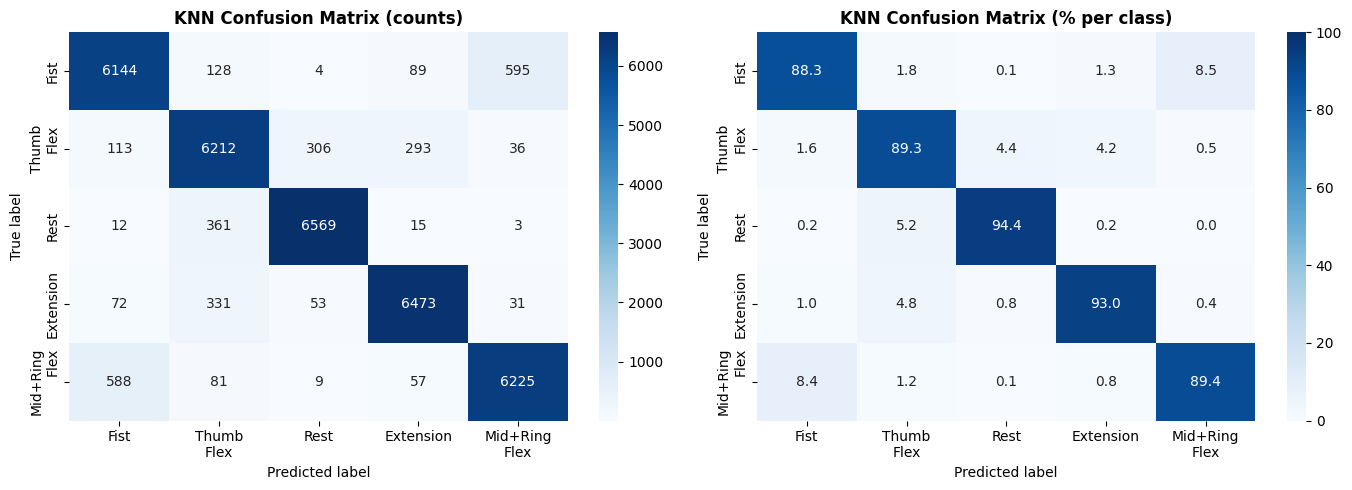

Confusion matrix saved as knn_confusion_matrix.png


In [ ]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Normalise to percentage (so each row sums to 100%)
cm_knn_norm = cm_knn.astype('float') / cm_knn.sum(axis=1)[:, np.newaxis] * 100

gesture_short_names = ['Fist', 'Thumb\nFlex', 'Rest', 'Extension', 'Mid+Ring\nFlex']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(
    cm_knn, annot=True, fmt='d',
    xticklabels=gesture_short_names,
    yticklabels=gesture_short_names,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('KNN Confusion Matrix (counts)', fontweight='bold')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Normalised percentages
sns.heatmap(
    cm_knn_norm, annot=True, fmt='.1f',
    xticklabels=gesture_short_names,
    yticklabels=gesture_short_names,
    cmap='Blues', ax=axes[1], vmin=0, vmax=100
)
axes[1].set_title('KNN Confusion Matrix (% per class)', fontweight='bold')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as knn_confusion_matrix.png")

---
## Step 7 — Train SVM and Compare with KNN

**SVM (Support Vector Machine)** is the most widely used classifier in EMG literature.

**How SVM works (simple explanation):**  
SVM finds the best boundary line (or hyperplane) that separates the gesture classes with the largest possible margin. It is very good at handling cases where classes are close together in feature space.

**Why compare with KNN?**  
- KNN is simple but slow at prediction time  
- SVM is faster at prediction and usually more accurate on EMG data  
- Comparing them is exactly what your project plan (Weeks 7–8) asks you to do

We use an **RBF (Radial Basis Function) kernel** which is the standard choice for EMG signals.

In [ ]:
# ── Train SVM classifier ───────────────────────────────────────────────────
# kernel='rbf'  : Radial Basis Function — best for non-linear EMG data
# C=1.0         : regularisation (higher C = less regularisation)
# gamma='scale' : automatic gamma based on feature variance

print("Training SVM classifier (RBF kernel)...")
print("This may take a few minutes on 174,000 samples.")
print()

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)

print("SVM training complete.")
print()

# ── Predict ────────────────────────────────────────────────────────────────
y_pred_svm = svm.predict(X_test)

# ── Accuracy ───────────────────────────────────────────────────────────────
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("=" * 50)
print(f"SVM Accuracy: {svm_accuracy * 100:.2f}%")
print("=" * 50)
print()

print("Classification Report (SVM):")
print(classification_report(
    y_test, y_pred_svm,
    target_names=['Fist', 'Thumb Flex', 'Rest', 'Extension', 'Mid+Ring Flex']
))

Training SVM classifier (RBF kernel)...
This may take a few minutes on 174,000 samples.

SVM training complete.

SVM Accuracy: 85.66%

Classification Report (SVM):
               precision    recall  f1-score   support

         Fist       0.84      0.79      0.82      6960
   Thumb Flex       0.81      0.81      0.81      6960
         Rest       0.89      0.93      0.91      6960
    Extension       0.92      0.90      0.91      6960
Mid+Ring Flex       0.82      0.85      0.83      6960

     accuracy                           0.86     34800
    macro avg       0.86      0.86      0.86     34800
 weighted avg       0.86      0.86      0.86     34800



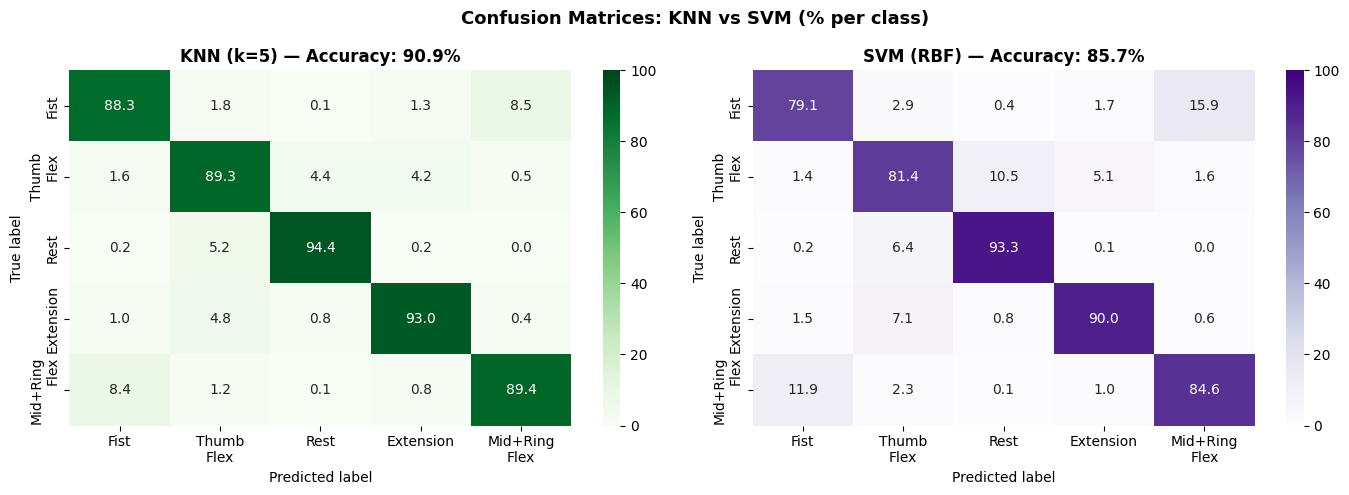


FINAL COMPARISON
KNN (k=5) accuracy : 90.87%
SVM (RBF) accuracy : 85.66%
KNN is better by   : 5.21%


In [ ]:
# ── Side-by-side comparison: KNN vs SVM ───────────────────────────────────
cm_svm      = confusion_matrix(y_test, y_pred_svm)
cm_svm_norm = cm_svm.astype('float') / cm_svm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_knn_norm, annot=True, fmt='.1f',
    xticklabels=gesture_short_names,
    yticklabels=gesture_short_names,
    cmap='Greens', ax=axes[0], vmin=0, vmax=100
)
axes[0].set_title(f'KNN (k=5) — Accuracy: {knn_accuracy*100:.1f}%', fontweight='bold')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

sns.heatmap(
    cm_svm_norm, annot=True, fmt='.1f',
    xticklabels=gesture_short_names,
    yticklabels=gesture_short_names,
    cmap='Purples', ax=axes[1], vmin=0, vmax=100
)
axes[1].set_title(f'SVM (RBF) — Accuracy: {svm_accuracy*100:.1f}%', fontweight='bold')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

plt.suptitle('Confusion Matrices: KNN vs SVM (% per class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_vs_svm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("=" * 50)
print("FINAL COMPARISON")
print("=" * 50)
print(f"KNN (k=5) accuracy : {knn_accuracy * 100:.2f}%")
print(f"SVM (RBF) accuracy : {svm_accuracy * 100:.2f}%")
diff = (svm_accuracy - knn_accuracy) * 100
if diff > 0:
    print(f"SVM is better by   : {diff:.2f}%")
elif diff < 0:
    print(f"KNN is better by   : {abs(diff):.2f}%")
else:
    print("Both classifiers are equal in accuracy.")
print("=" * 50)

---
## Summary — What You Have Achieved

Congratulations! You have completed the full **Semester 1 ML pipeline** for EMG gesture recognition.

| What you did | Result |
|-------------|--------|
| Loaded and explored DS1 dataset | 174,000 windows, 3 channels, 5 gestures |
| Visualised raw EMG per gesture | Confirmed physiology — flexors active during fist, extensors during extension |
| Extracted 4 features × 3 channels | 12-feature vector per window |
| Trained KNN (k=5) | Baseline classifier |
| Trained SVM (RBF) | Better accuracy, standard in EMG literature |
| Compared both with confusion matrix | Identified which gestures are harder to classify |

---

## Next Steps (Weeks 9–12 of your project plan)

1. **Add more features** — try adding variance, slope sign changes, mean frequency
2. **Try Random Forest** — another strong classifier for EMG (`sklearn.ensemble.RandomForestClassifier`)
3. **Cross-validation** — use `sklearn.model_selection.cross_val_score` for more reliable accuracy
4. **Subject-wise testing** — train on some subjects, test on others (tests generalisation)
5. **Load BioRadio data** — replace DS1 data with your own collected data and re-run this pipeline

---

> **Note for your report:** When writing about your ML approach, cite both the dataset paper (Zúñiga-Castillo et al., 2025) and the feature extraction methods (RMS, MAV are from SENIAM standards). Your confusion matrix and accuracy table go directly into your Mid-Semester Evaluation report.